*Pipeline for preprocessing EEG*

1. Import data
2. Set montage
3. Set average reference
4. Filter: band pass + 0.5–40 Hz band-pass
5. Downsample to 256 Hz
6. Inspepct, mark and interpolate bad channels
9. Set average reference again
10. ICA

# 0. Extras

Load packages

In [1]:
import pickle
import mne
import os
import ipywidgets as widgets
import matplotlib
import matplotlib.pyplot as plt
import sklearn
matplotlib.use('TkAgg')
%matplotlib inline
# set size of raw browser
mne.utils.config.set_config('MNE_BROWSE_RAW_SIZE','16.0,8.0')

In [5]:
#@title
def inspect_raw(craw,start, chan_sel,nchan=10,time_step=2,events=None):
    order = np.arange(nchan, dtype = int) + int(nchan*(chan_sel-1))
    order = order[order < len(raw.ch_names)]
    cfig = craw.plot(events = events, start = start, duration = time_step,
                     order = order,show_scrollbars = False)

def raw_interact(craw, time_step=2, nchan=63, events=None):
    _ = widgets.interact(
        inspect_raw,
        craw=widgets.fixed(craw),
        nchan=widgets.fixed(nchan),
        time_step=widgets.fixed(time_step),
        events=widgets.fixed(events),

        start=widgets.FloatSlider(
            value=0,
            min=0,
            max=craw.times[-1],
            step=time_step,
            description="time"
        ),

        chan_sel=widgets.IntSlider(
            value=1,
            min=1,
            max=int(np.ceil(len(craw.ch_names) / nchan)),
            step=1,
            description="chan group"
        )
    )

# 1. Preprocessing 

## 1.1 Import Data

In [2]:
from pathlib import Path

data_dir = Path.cwd()
file01 = data_dir /"EEG_DATA"/"07.vhdr"

raw = mne.io.read_raw_brainvision(file01, preload=True)

events, event_id = mne.events_from_annotations(raw)

print(raw.ch_names)


Extracting parameters from c:\Users\freja\OneDrive\Documents\KDV\4 Sem\EM3\Data\EEG_DATA\07.vhdr...
Setting channel info structure...


C:\Users\freja\AppData\Local\Temp\ipykernel_144\1909586476.py:6: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(file01, preload=True)


Reading 0 ... 2399979  =      0.000 ...  2399.979 secs...
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S 23'), np.str_('Stimulus/S 24'), np.str_('Stimulus/S 25'), np.str_('Stimulus/S 26'), np.str_('Stimulus/S 51'), np.str_('Stimulus/S 52'), np.str_('Stimulus/S 53'), np.str_('Stimulus/S 54'), np.str_('Stimulus/S 55'), np.str_('Stimulus/S 56'), np.str_('Stimulus/S 71'), np.str_('Stimulus/S 72'), np.str_('Stimulus/S 73'), np.str_('Stimulus/S 74'), np.str_('Stimulus/S 75'), np.str_('Stimulus/S 76')]
['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2', 'FCz']


## 1.2-1.5.

In [3]:
#2. Set montage

# Use standard montage 
montage_std = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage_std, match_case=False, on_missing='ignore')

#3. Set avg. reference
raw.set_eeg_reference("average")

#4. Filter 
raw_filtered = raw.copy()
raw_filtered.filter(l_freq=0.5, h_freq=40)

#5. Downsample
raw_filtered, events_resampled = raw_filtered.resample(
    sfreq=256,
    events = events 
)

print("\nSampling frequency after resampling:")
print(raw_filtered.info["sfreq"])

print("\nFirst 10 resampled events:")
print(events_resampled[:10])

print("\nUnique event codes after resampling:")
print(sorted(set(events_resampled[:, 2])))

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 6601 samples (6.601 s)


Sampling frequency after resampling:
256.0

First 10 resampled events:
[[21110     0    54]
 [22377     0    51]
 [23627     0    55]
 [24890     0    56]
 [26277     0    54]
 [27480     0    51]
 [28816     0    54]
 [30083     0    52]
 [31623     0    52]
 [32976     0    54]]

Unique event codes after resampling:
[np.

## 1.6. Remove bad channels 

In [6]:
#Inspect data 
import numpy as np

raw_interact(raw_filtered, time_step=2, nchan=10)

interactive(children=(FloatSlider(value=0.0, description='time', max=2399.9765625, step=2.0), IntSlider(value=…

Remove bad channels if needed 

In [7]:
raw_filtered.info["bads"] = ["F7", "FT9", "FT8", "FT7", "Fp2", "T8", "C6" ,"Fp1", "O1", "TP10"]

#Interpolate bad channels
raw_interpolated = raw_filtered.copy()
raw_interpolated.interpolate_bads(reset_bads=True)

#set reference again 
raw_interpolated.set_eeg_reference("average")
#i see no bad channelse

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.7 mm
Computing interpolation matrix from 53 sensor positions
Interpolating 10 sensors
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawBrainVision | 07.eeg, 63 x 614395 (2400.0 s), ~295.4 MiB, data loaded>

## 1.7. Set average reference again

In [ ]:
raw_interact(raw_interpolated, time_step=2, nchan=10)

interactive(children=(FloatSlider(value=0.0, description='time', max=2399.9765625, step=2.0), IntSlider(value=…

## 1.8. Epoching


In [10]:

# Six analysis conditions used throughout the open-science RewP/FRN analysis
YIN_EVENT_GROUPS = {
    "low_near_miss": ["Stimulus/S 25", "Stimulus/S 26"],
    "low_full_miss": ["Stimulus/S 24"],

    "medium_near_miss": ["Stimulus/S 55", "Stimulus/S 56"],
    "medium_full_miss": ["Stimulus/S 54"],

    "high_near_miss": ["Stimulus/S 75", "Stimulus/S 76"],
    "high_full_miss": ["Stimulus/S 74"],
}

YIN_EXPECTANCY_LEVELS = ["low", "medium", "high"]
YIN_OUTCOMES = ["near_miss", "full_miss"]

# Event IDs for conditions
YIN_EVENT_ID = {
    condition_name: code
    for code, condition_name in enumerate(YIN_EVENT_GROUPS.keys(), start=1)
}

# -------------------------------------------------------------------------
# Recode original marker events into the six Yin analysis conditions
# -------------------------------------------------------------------------

events_yin = events.copy()
keep_mask = np.zeros(len(events_yin), dtype=bool)

for condition_name, marker_names in YIN_EVENT_GROUPS.items():

    new_code = YIN_EVENT_ID[condition_name]
    original_codes = [event_id_all[marker] for marker in marker_names]

    condition_mask = np.isin(events_yin[:, 2], original_codes)
    events_yin[condition_mask, 2] = new_code
    keep_mask = keep_mask | condition_mask

    print(f"{condition_name}: {condition_mask.sum()} events")

# Keep only the six conditions needed for the Yin RewP/FRN analysis
events_yin = events_yin[keep_mask]

print("\nNumber of Yin analysis events:", len(events_yin))
print("YIN_EVENT_ID:", YIN_EVENT_ID)


low_near_miss: 40 events
low_full_miss: 40 events
medium_near_miss: 40 events
medium_full_miss: 40 events
high_near_miss: 40 events
high_full_miss: 40 events

Number of Yin analysis events: 240
YIN_EVENT_ID: {'low_near_miss': 1, 'low_full_miss': 2, 'medium_near_miss': 3, 'medium_full_miss': 4, 'high_near_miss': 5, 'high_full_miss': 6}


## 1.9. ICA on epochs 

In [13]:
#create epochs
epochs_before_ica = mne.Epochs(
    raw_interpolated,
    events=events_yin,
    event_id=YIN_EVENT_ID,
    tmin=-2.5,
    tmax=2.0,
    baseline=None,
    preload=True,
    reject_by_annotation=True
)

print(epochs_before_ica)
print("\nEpoch event IDs:")
print(epochs_before_ica.event_id)


Not setting metadata
240 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 240 events and 1153 original time points ...
0 bad epochs dropped
<Epochs | 240 events (all good), -2.5 – 2 s (baseline off), ~133.1 MiB, data loaded,
 'low_near_miss': 40
 'low_full_miss': 40
 'medium_near_miss': 40
 'medium_full_miss': 40
 'high_near_miss': 40
 'high_full_miss': 40>

Epoch event IDs:
{'low_near_miss': 1, 'low_full_miss': 2, 'medium_near_miss': 3, 'medium_full_miss': 4, 'high_near_miss': 5, 'high_full_miss': 6}


In [14]:
# =============================================================================
# Fit ICA on the full-stop epochs
# =============================================================================
ica = mne.preprocessing.ICA(
    n_components=30,
    random_state=97,
    max_iter="auto"
)

ica.fit(epochs_before_ica)

print(ica)

Fitting ICA to data using 63 channels (please be patient, this may take a while)
Selecting by number: 30 components


C:\Users\freja\AppData\Local\Temp\ipykernel_144\835450778.py:10: RuntimeWarning: Using n_components=30 (resulting in n_components_=30) may lead to an unstable mixing matrix estimation because the ratio between the largest (61) and smallest (1.1e-05) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 18
  ica.fit(epochs_before_ica)


Fitting ICA took 7.4s.
<ICA | epochs decomposition, method: fastica (fit in 39 iterations on 276720 samples), 30 ICA components (63 PCA components available), channel types: eeg, no sources marked for exclusion>


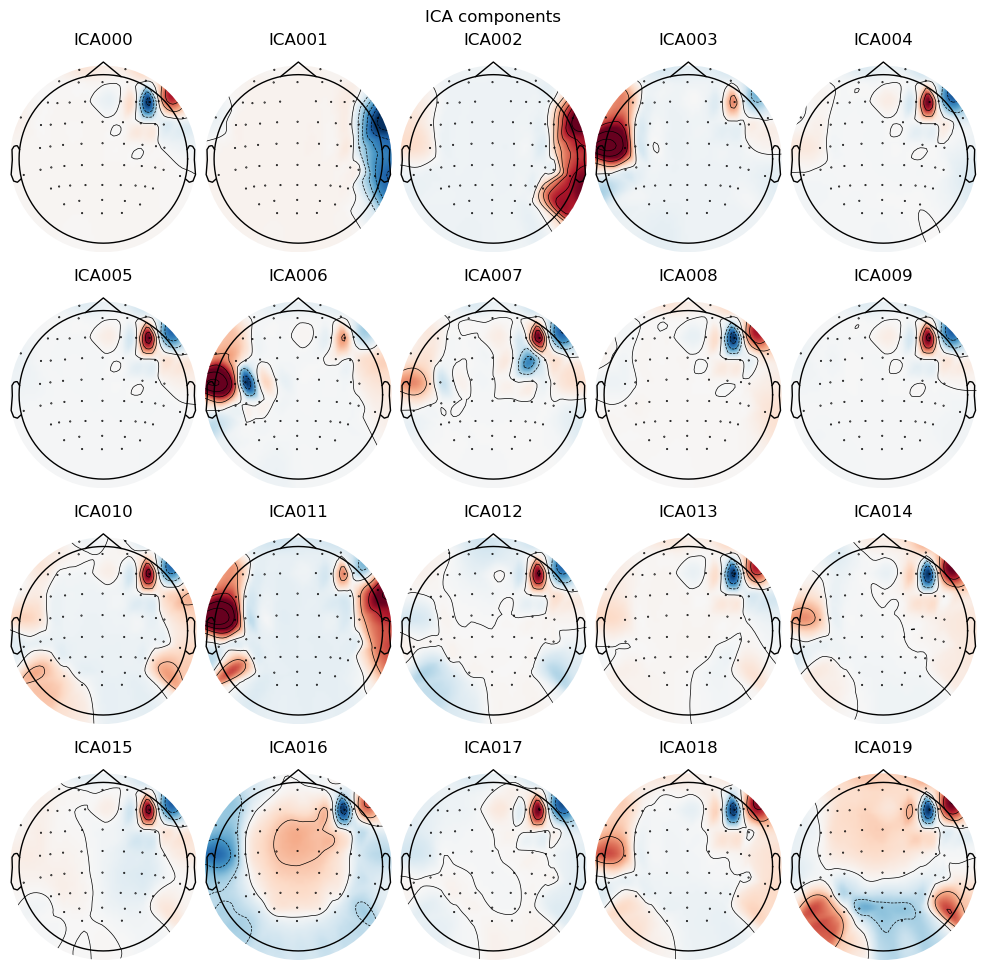

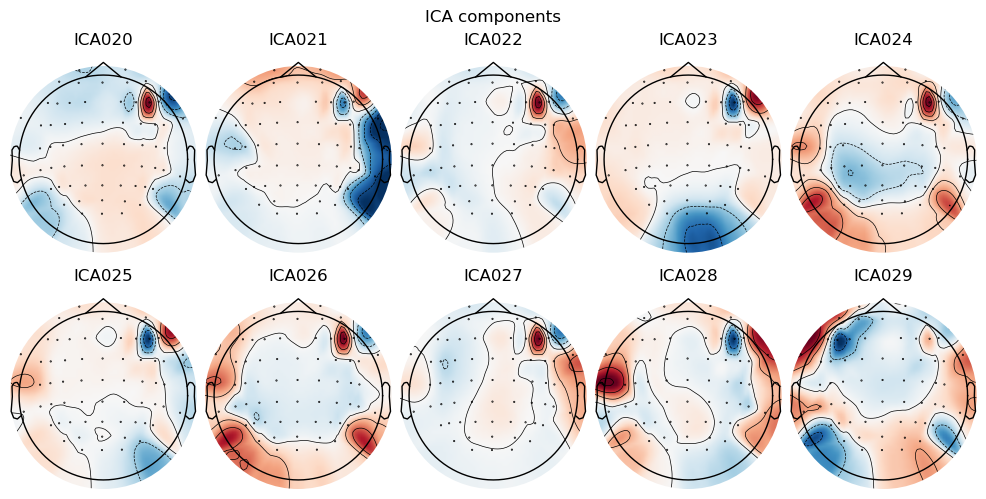

Not setting metadata
360 matching events found
No baseline correction applied
0 projection items activated


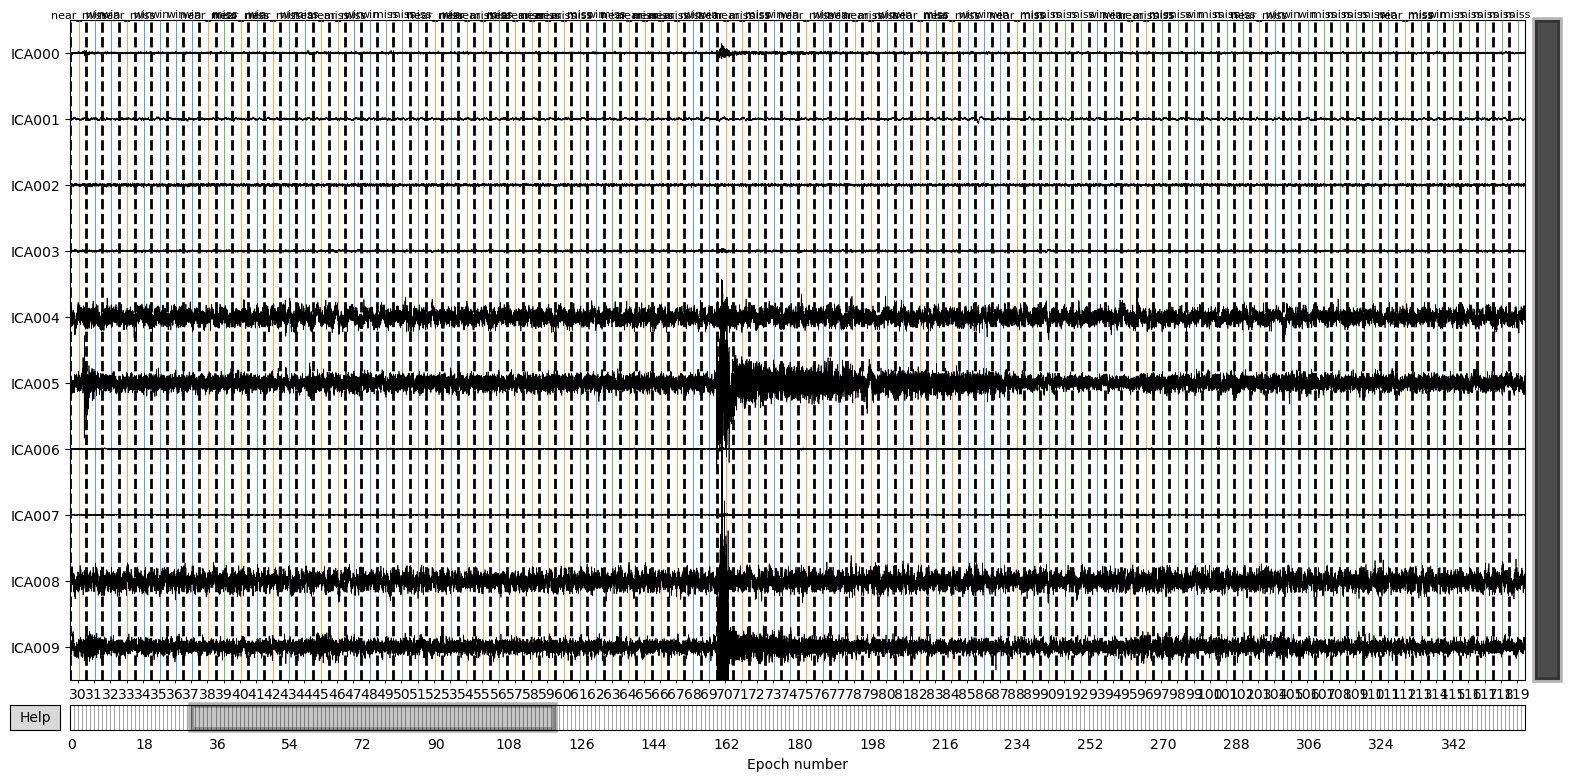

Not setting metadata
360 matching events found
No baseline correction applied
0 projection items activated


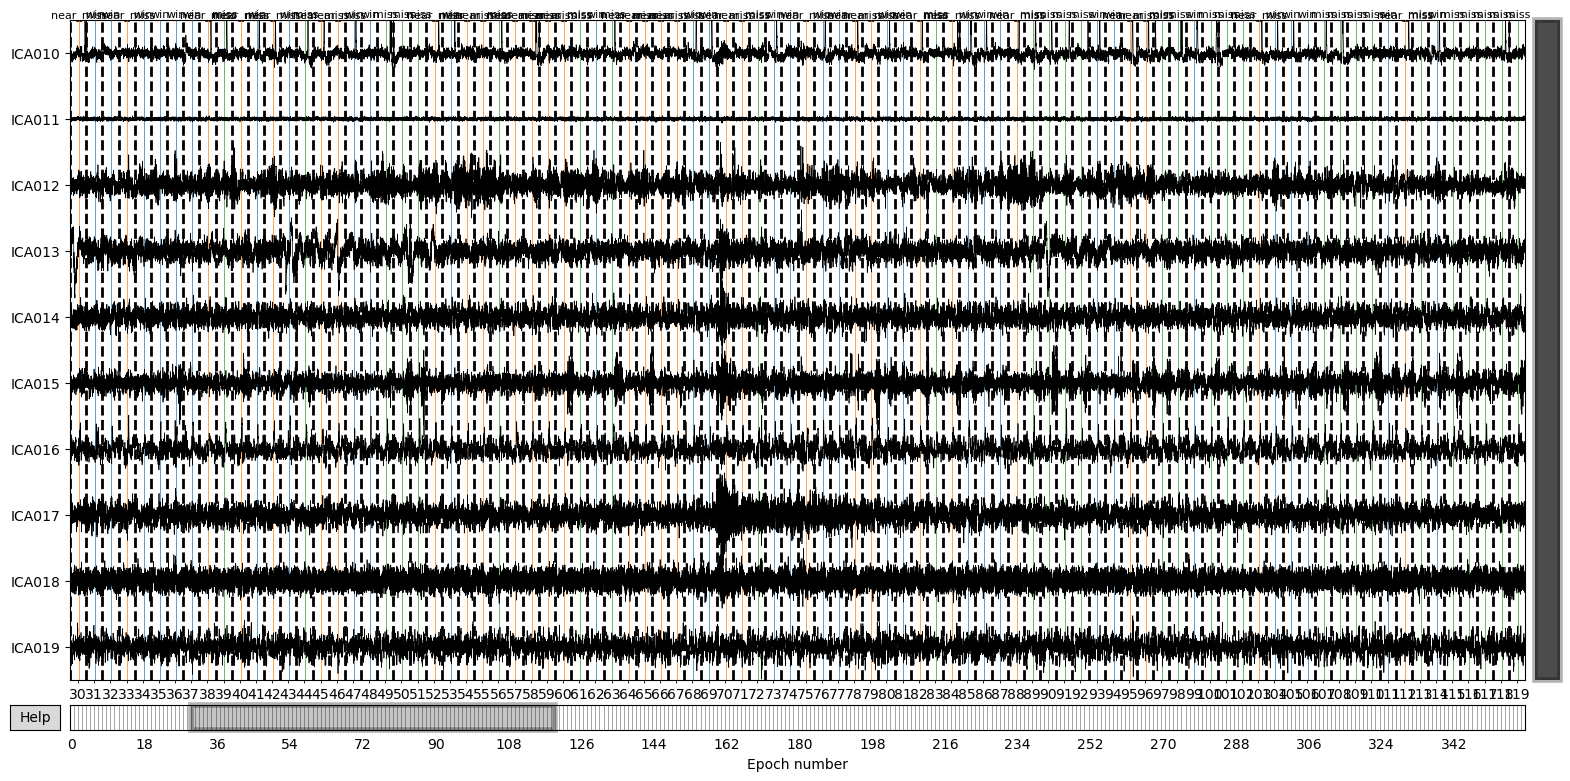

Not setting metadata
360 matching events found
No baseline correction applied
0 projection items activated


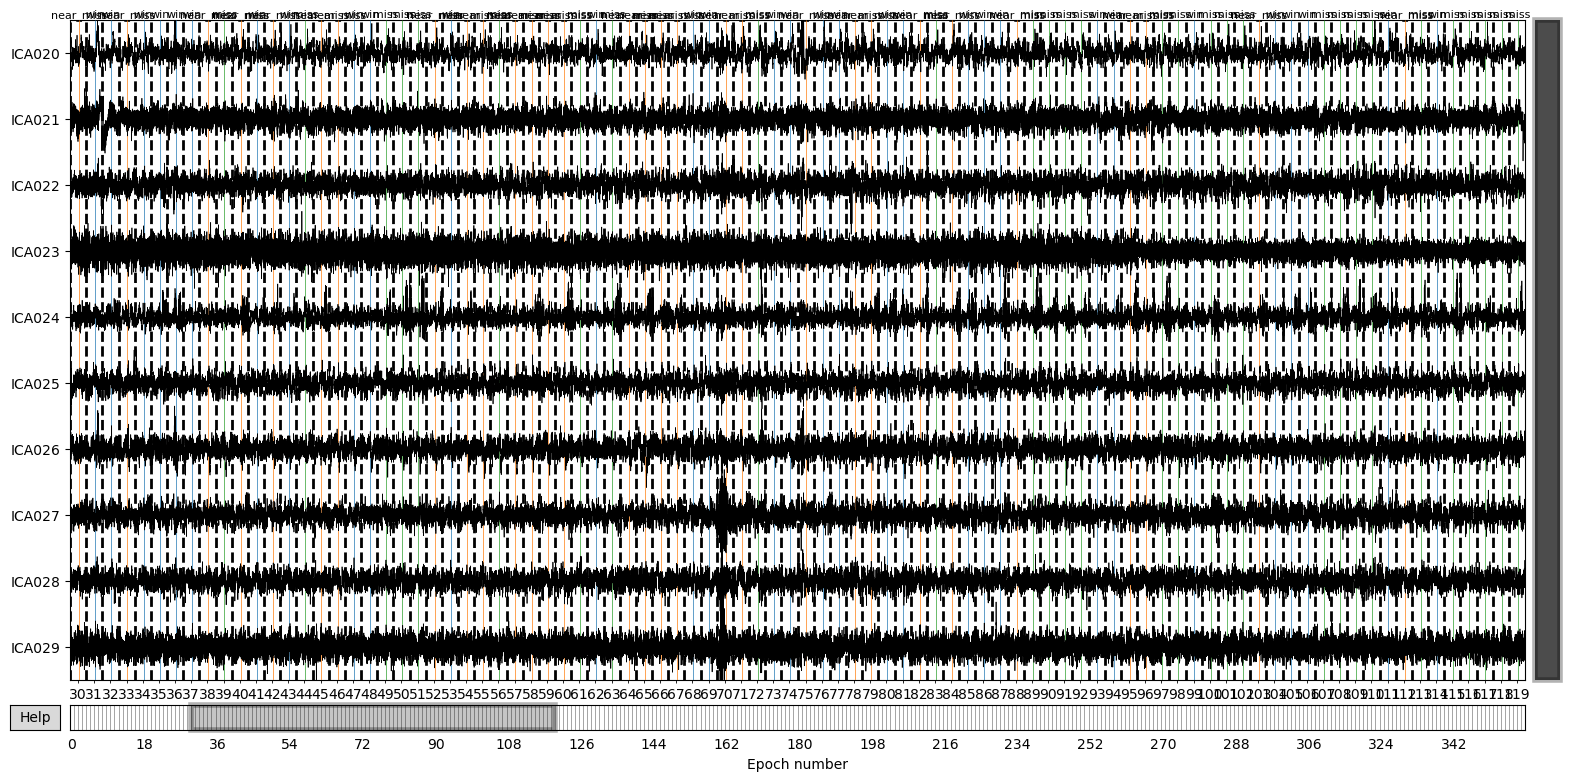

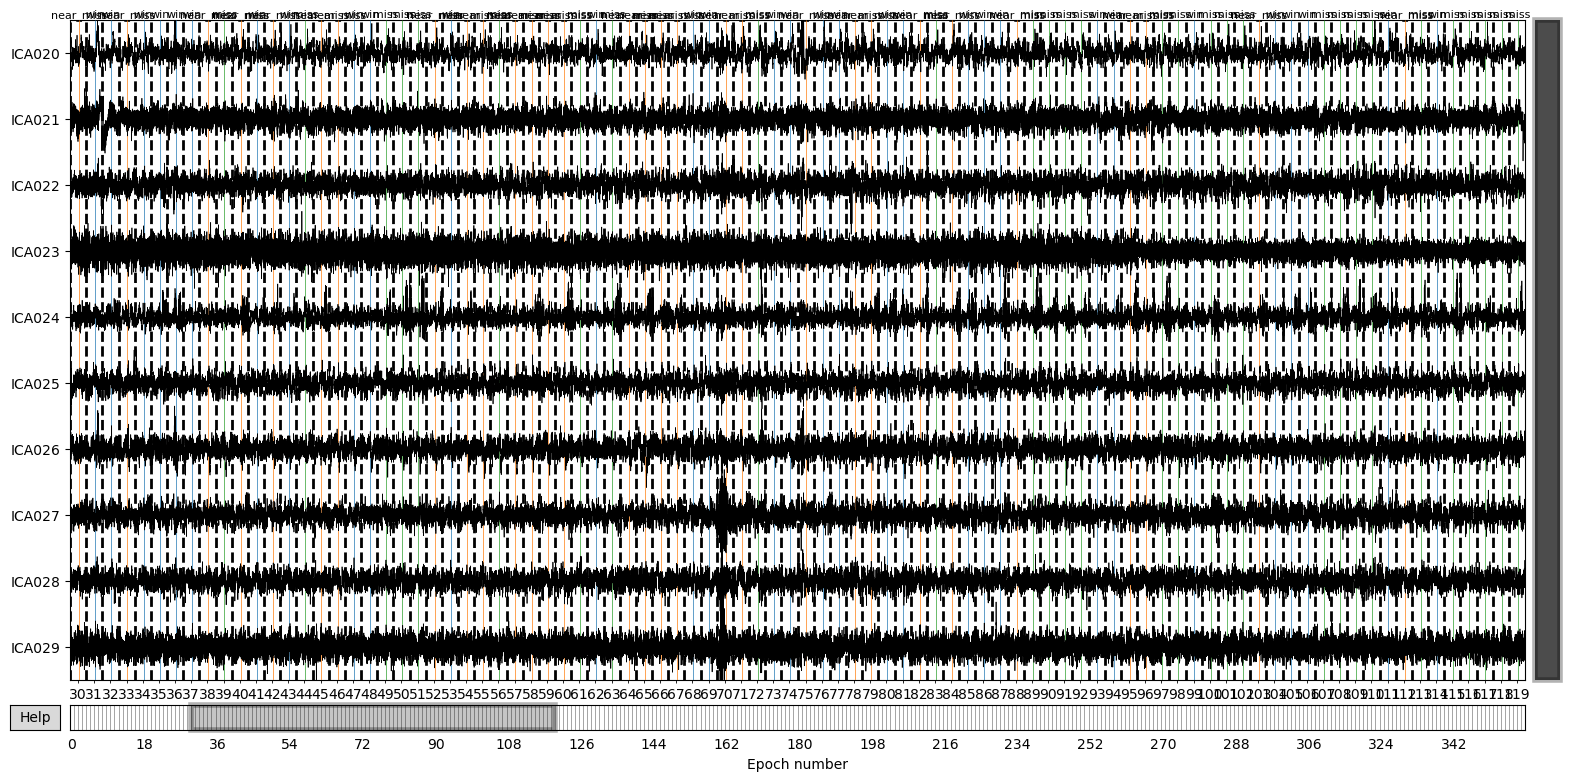

In [13]:
# =============================================================================
# Inspect ICA components
# =============================================================================
ica.plot_components()
ica.plot_sources(
    epochs_before_ica,
    picks=range(0, 10),
    start=30,
    stop=120
)
ica.plot_sources(
    epochs_before_ica,
    picks=range(10, 20),
    start=30,
    stop=120
)
ica.plot_sources(
    epochs_before_ica,
    picks=range(20, 30),
    start=30,
    stop=120
)



Applying ICA to Epochs instance
    Transforming to ICA space (30 components)
    Zeroing out 3 ICA components
    Projecting back using 63 PCA components


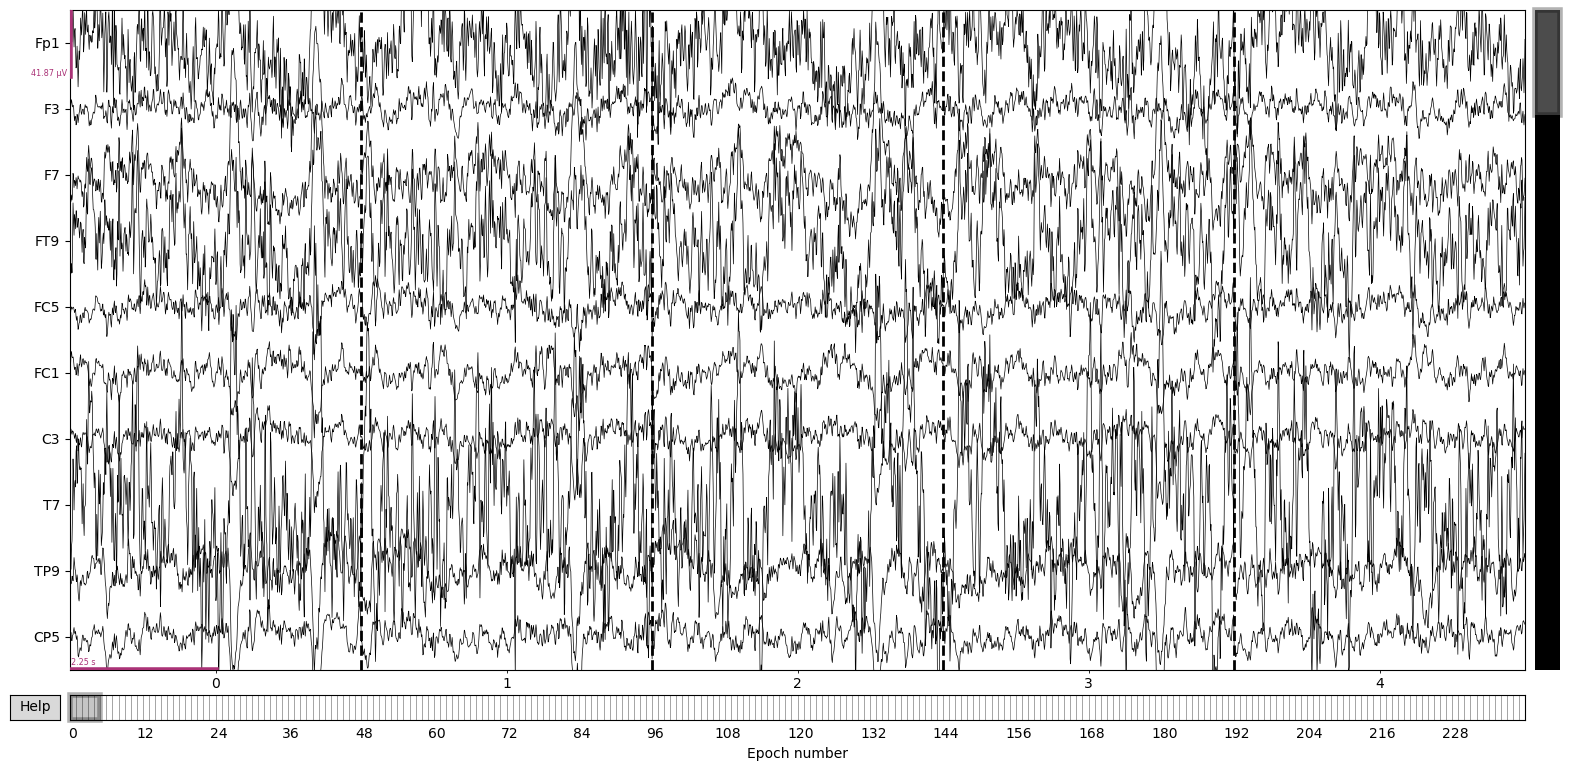

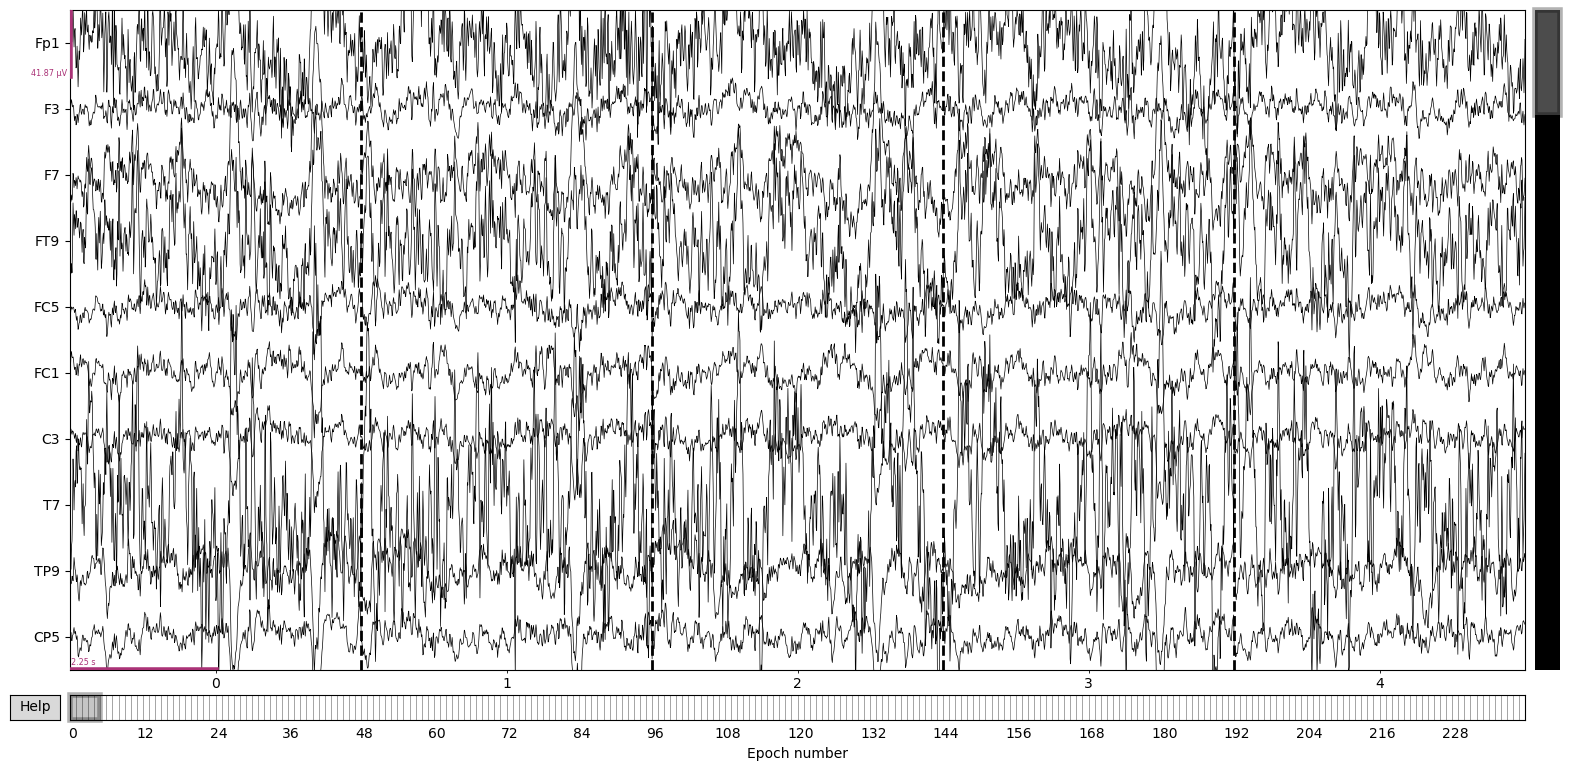

In [16]:
# =============================================================================
# Choose ICA components to remove
# =============================================================================

ica.exclude = [1,2,3]

# =============================================================================
# Apply ICA to the long epochs
# =============================================================================
# We apply ICA to a COPY of the epochs.
# The original epochs_full_stop stays unchanged.
# =============================================================================

epochs_ica = epochs_before_ica.copy()
ica.apply(epochs_ica)

epochs_ica.plot(
    n_epochs=5,
    n_channels=10,
    scalings="auto"
)



## 1.10. Baseline

In [17]:
# =============================================================================
# Create baseline-corrected epochs and ERP dictionaries
# =============================================================================
# For the open-science RewP/FRN analysis, use epochs_rewp_lpp_ica.
# ERPs_rewp_lpp_ica is only for plotting averaged waveforms.
# The statistical tests use single-trial epochs, not averaged ERPs.
# =============================================================================

# RewP/FRN and P300/LPP baseline: -100 to 0 ms before outcome/R3
epochs_rewp_lpp_ica = epochs_ica.copy().apply_baseline(
    baseline=(-0.100, 0.000)
)

# SPN baseline, if needed for your own slot-machine analysis
epochs_spn_ica = epochs_ica.copy().apply_baseline(
    baseline=(-2.400, -2.300)
)

# ERP dictionaries are created once and reused for plotting only
ERPs_rewp_lpp_ica = {
    cond: epochs_rewp_lpp_ica[cond].average()
    for cond in epochs_rewp_lpp_ica.event_id.keys()
}

ERPs_spn_ica = {
    cond: epochs_spn_ica[cond].average()
    for cond in epochs_spn_ica.event_id.keys()
}

print("RewP/LPP epoch conditions:")
print(epochs_rewp_lpp_ica.event_id)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
RewP/LPP epoch conditions:
{'low_near_miss': 1, 'low_full_miss': 2, 'medium_near_miss': 3, 'medium_full_miss': 4, 'high_near_miss': 5, 'high_full_miss': 6}


# 2. Analysis

## 2.1 FRN/RewP at FCz, 200–300 ms

This analysis compares near-miss vs full-miss trials separately for low, medium, and high reward expectancy.



In [24]:
# =============================================================================
# Open-science primary analysis: Yin FRN/RewP at FCz, 200–300 ms
# =============================================================================

from scipy import stats
from mne.stats import permutation_cluster_test

# -------------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------------

REWP_CHANNEL = "FCz"
REWP_TMIN = 0.228
REWP_TMAX = 0.344

PLOT_TMIN = -0.100
PLOT_TMAX = 0.600

N_PERMUTATIONS = 5000
ALPHA = 0.05
CLUSTER_ALPHA = 0.05

near_color = "#D130AA"
full_color = "#160090"

# -------------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------------

def get_condition_epochs(epochs, condition_name):
    """Return epochs for one named condition and give a clear error if missing."""
    if condition_name not in epochs.event_id:
        raise KeyError(
            f"Condition '{condition_name}' not found. Available conditions are: "
            f"{list(epochs.event_id.keys())}"
        )
    return epochs[condition_name]


def extract_single_trial_data(epochs, condition_name, channel, tmin, tmax):
    """
    Extract single-trial data for one condition.
    Returns:
        X: trials x time, in volts
        times_ms: time vector in ms
    """
    ep = get_condition_epochs(epochs, condition_name)
    ep_crop = ep.copy().pick(channel).crop(tmin=tmin, tmax=tmax)
    X = ep_crop.get_data()[:, 0, :]
    times_ms = ep_crop.times * 1000
    return X, times_ms


def welch_t_stat(X_near, X_full):
    """Welch t-statistic at each time point for permutation_cluster_test."""
    return stats.ttest_ind(
        X_near,
        X_full,
        axis=0,
        equal_var=False,
        nan_policy="omit"
    ).statistic


def summarize_mean_amplitude(X):
    """
    Convert trial-level mean amplitudes from volts to microvolts.
    Returns mean, SD, SEM and trial-level values.
    """
    trial_means_uv = X.mean(axis=1) * 1e6
    mean_uv = trial_means_uv.mean()
    sd_uv = trial_means_uv.std(ddof=1)
    sem_uv = sd_uv / np.sqrt(len(trial_means_uv))
    return mean_uv, sd_uv, sem_uv, trial_means_uv

# -------------------------------------------------------------------------
# Run analysis
# -------------------------------------------------------------------------

rewp_results = {}

for expectancy in YIN_EXPECTANCY_LEVELS:

    near_condition = f"{expectancy}_near_miss"
    full_condition = f"{expectancy}_full_miss"

    print("\n" + "=" * 80)
    print(f"Yin FRN/RewP analysis: {expectancy.upper()} expectancy")
    print("=" * 80)

    # Extract single-trial data in the RewP/FRN window
    X_near, times_ms = extract_single_trial_data(
        epochs_rewp_lpp_ica,
        near_condition,
        REWP_CHANNEL,
        REWP_TMIN,
        REWP_TMAX
    )

    X_full, _ = extract_single_trial_data(
        epochs_rewp_lpp_ica,
        full_condition,
        REWP_CHANNEL,
        REWP_TMIN,
        REWP_TMAX
    )

    print("Data shapes:")
    print(f"Near-miss: {X_near.shape}")
    print(f"Full-miss: {X_full.shape}")

    # Descriptive statistics
    near_mean, near_sd, near_sem, near_trial_means = summarize_mean_amplitude(X_near)
    full_mean, full_sd, full_sem, full_trial_means = summarize_mean_amplitude(X_full)
    diff_mean = near_mean - full_mean

    print(f"\nMean amplitude at FCz, {REWP_TMIN * 1000:.0f}–{REWP_TMAX * 1000:.0f} ms")
    print("----------------------------------")
    print(f"Near-miss: M = {near_mean:.3f} µV, SD = {near_sd:.3f}, SEM = {near_sem:.3f}, n = {len(near_trial_means)}")
    print(f"Full-miss: M = {full_mean:.3f} µV, SD = {full_sd:.3f}, SEM = {full_sem:.3f}, n = {len(full_trial_means)}")
    print(f"Near-miss - full-miss = {diff_mean:.3f} µV")

    # Trial-level Welch t-test on mean amplitudes
    t_mean, p_mean = stats.ttest_ind(
        near_trial_means,
        full_trial_means,
        equal_var=False
    )

    print("\nTrial-level Welch t-test on mean amplitude")
    print("------------------------------------------")
    print(f"t = {t_mean:.3f}, p = {p_mean:.4f}")

    # Cluster-forming threshold for a two-tailed t-test
    # This is an approximate df for the threshold. The permutation p-values are the main result.
    df_approx = len(near_trial_means) + len(full_trial_means) - 2
    t_threshold = stats.t.ppf(1 - CLUSTER_ALPHA / 2, df_approx)

    T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
        [X_near, X_full],
        stat_fun=welch_t_stat,
        threshold=t_threshold,
        n_permutations=N_PERMUTATIONS,
        tail=0,
        out_type="indices",
        seed=42
    )

    print("\nCluster-based permutation test")
    print("------------------------------")

    sig_cluster_found = False
    cluster_summaries = []

    for i, p_cluster in enumerate(cluster_p_values):
        cluster_indices = clusters[i][0]
        cluster_times = times_ms[cluster_indices]
        mean_stat = T_obs[cluster_indices].mean()

        print(f"\nCluster {i + 1}")
        print(f"p = {p_cluster:.4f}")
        print(f"time window = {cluster_times[0]:.1f} to {cluster_times[-1]:.1f} ms")
        print(f"mean t-value = {mean_stat:.3f}")

        cluster_summaries.append({
            "cluster": i + 1,
            "p": p_cluster,
            "start_ms": cluster_times[0],
            "end_ms": cluster_times[-1],
            "mean_t": mean_stat,
            "significant": p_cluster < ALPHA
        })

        if p_cluster < ALPHA:
            sig_cluster_found = True
            print("SIGNIFICANT")

    if not sig_cluster_found:
        print("\nNo significant clusters were found.")

    rewp_results[expectancy] = {
        "near_condition": near_condition,
        "full_condition": full_condition,
        "X_near": X_near,
        "X_full": X_full,
        "times_ms": times_ms,
        "near_mean": near_mean,
        "near_sd": near_sd,
        "near_sem": near_sem,
        "full_mean": full_mean,
        "full_sd": full_sd,
        "full_sem": full_sem,
        "diff_mean": diff_mean,
        "t_mean": t_mean,
        "p_mean": p_mean,
        "T_obs": T_obs,
        "clusters": clusters,
        "cluster_p_values": cluster_p_values,
        "cluster_summaries": cluster_summaries
    }



Yin FRN/RewP analysis: LOW expectancy
Data shapes:
Near-miss: (40, 31)
Full-miss: (40, 31)

Mean amplitude at FCz, 228–344 ms
----------------------------------
Near-miss: M = 7.501 µV, SD = 69.604, SEM = 11.005, n = 40
Full-miss: M = 17.562 µV, SD = 73.254, SEM = 11.582, n = 40
Near-miss - full-miss = -10.061 µV

Trial-level Welch t-test on mean amplitude
------------------------------------------
t = -0.630, p = 0.5307
stat_fun(H1): min=-0.9799975699685697 max=-0.4167118369184461
Running initial clustering …
Found 0 clusters

Cluster-based permutation test
------------------------------

No significant clusters were found.

Yin FRN/RewP analysis: MEDIUM expectancy


C:\Users\freja\AppData\Local\Temp\ipykernel_144\2215559924.py:139: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Data shapes:
Near-miss: (40, 31)
Full-miss: (40, 31)

Mean amplitude at FCz, 228–344 ms
----------------------------------
Near-miss: M = 10.876 µV, SD = 5.723, SEM = 0.905, n = 40
Full-miss: M = 10.254 µV, SD = 7.031, SEM = 1.112, n = 40
Near-miss - full-miss = 0.623 µV

Trial-level Welch t-test on mean amplitude
------------------------------------------
t = 0.434, p = 0.6653
stat_fun(H1): min=-1.1637136592119532 max=1.6177631407281505
Running initial clustering …
Found 0 clusters

Cluster-based permutation test
------------------------------

No significant clusters were found.

Yin FRN/RewP analysis: HIGH expectancy
Data shapes:
Near-miss: (40, 31)
Full-miss: (40, 31)

Mean amplitude at FCz, 228–344 ms
----------------------------------
Near-miss: M = 14.175 µV, SD = 105.700, SEM = 16.713, n = 40
Full-miss: M = 17.224 µV, SD = 91.022, SEM = 14.392, n = 40
Near-miss - full-miss = -3.049 µV

Trial-level Welch t-test on mean amplitude
------------------------------------------
t = -0.

C:\Users\freja\AppData\Local\Temp\ipykernel_144\2215559924.py:139: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
C:\Users\freja\AppData\Local\Temp\ipykernel_144\2215559924.py:139: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


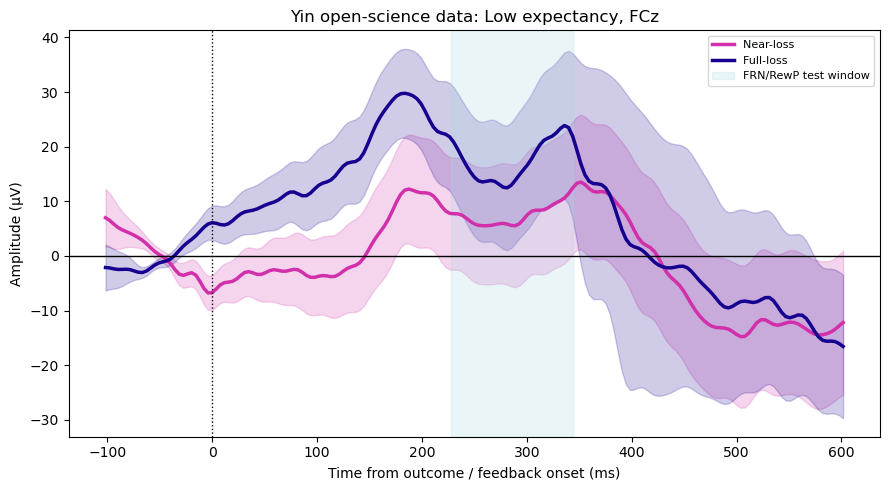

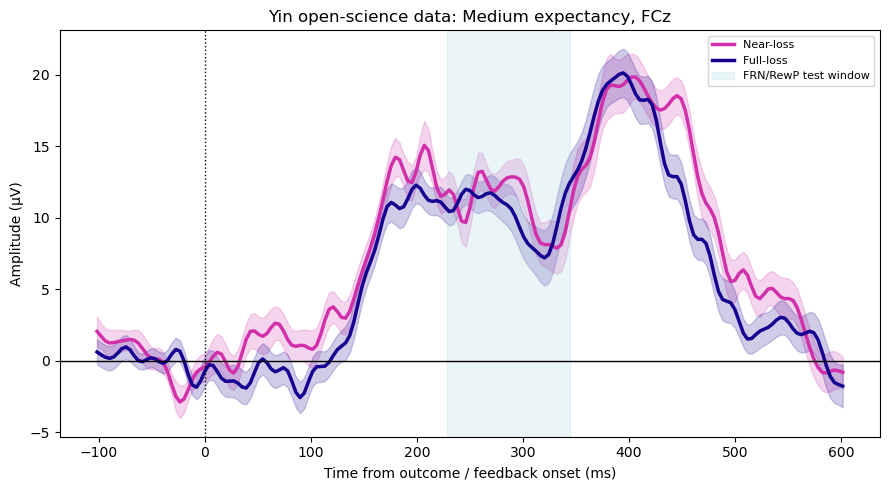

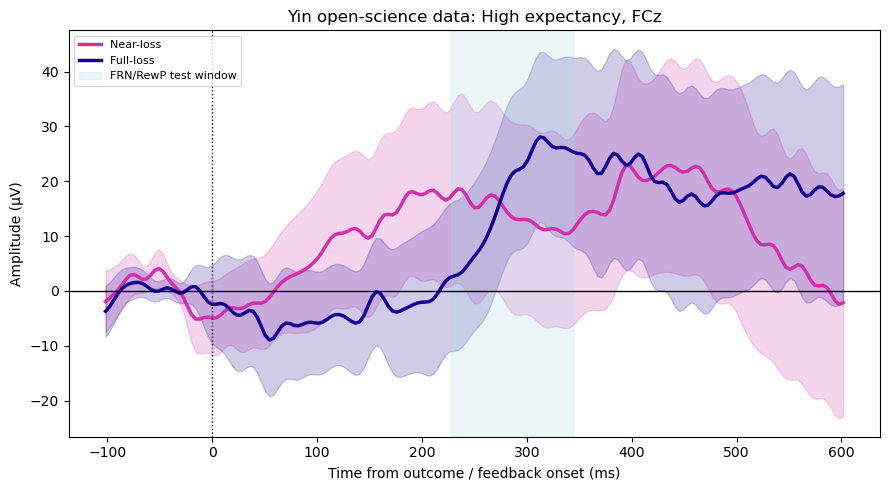

In [27]:
# =============================================================================
# Plot Yin FRN/RewP waveforms: near-miss vs full-miss by expectancy
# with SEM shading across the full plotting window
# =============================================================================

for expectancy in YIN_EXPECTANCY_LEVELS:

    result = rewp_results[expectancy]

    near_condition = result["near_condition"]
    full_condition = result["full_condition"]

    # -------------------------------------------------------------------------
    # Extract full plotting window from the original epochs
    # -------------------------------------------------------------------------

    epochs_near_plot = (
        epochs_rewp_lpp_ica[near_condition]
        .copy()
        .pick(REWP_CHANNEL)
        .crop(tmin=PLOT_TMIN, tmax=PLOT_TMAX)
    )

    epochs_full_plot = (
        epochs_rewp_lpp_ica[full_condition]
        .copy()
        .pick(REWP_CHANNEL)
        .crop(tmin=PLOT_TMIN, tmax=PLOT_TMAX)
    )

    # -------------------------------------------------------------------------
    # Get single-trial data for the full plotting window
    # -------------------------------------------------------------------------

    X_near_plot_uv = epochs_near_plot.get_data()[:, 0, :] * 1e6
    X_full_plot_uv = epochs_full_plot.get_data()[:, 0, :] * 1e6

    times_ms = epochs_near_plot.times * 1000

    # -------------------------------------------------------------------------
    # Mean waveform and SEM waveform
    # -------------------------------------------------------------------------

    near_mean_wave = X_near_plot_uv.mean(axis=0)
    full_mean_wave = X_full_plot_uv.mean(axis=0)

    near_sem_wave = (
        X_near_plot_uv.std(axis=0, ddof=1)
        / np.sqrt(X_near_plot_uv.shape[0])
    )

    full_sem_wave = (
        X_full_plot_uv.std(axis=0, ddof=1)
        / np.sqrt(X_full_plot_uv.shape[0])
    )

    # -------------------------------------------------------------------------
    # Plot
    # -------------------------------------------------------------------------

    plt.figure(figsize=(9, 5))

    # Near-miss waveform
    plt.plot(
        times_ms,
        near_mean_wave,
        color=near_color,
        linewidth=2.5,
        label=(
            f"Near-loss "
        )
    )

    plt.fill_between(
        times_ms,
        near_mean_wave - near_sem_wave,
        near_mean_wave + near_sem_wave,
        color=near_color,
        alpha=0.20
    )

    # Full-miss waveform
    plt.plot(
        times_ms,
        full_mean_wave,
        color=full_color,
        linewidth=2.5,
        label=(
            f"Full-loss "
        )
    )

    plt.fill_between(
        times_ms,
        full_mean_wave - full_sem_wave,
        full_mean_wave + full_sem_wave,
        color=full_color,
        alpha=0.20
    )

    # -------------------------------------------------------------------------
    # Reference lines
    # -------------------------------------------------------------------------

    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="black", linestyle=":", linewidth=1)

    # -------------------------------------------------------------------------
    # FRN/RewP test window
    # -------------------------------------------------------------------------

    plt.axvspan(
        REWP_TMIN * 1000,
        REWP_TMAX * 1000,
        color="lightblue",
        alpha=0.25,
        label="FRN/RewP test window"
    )

    # -------------------------------------------------------------------------
    # Mark significant clusters, if any
    # -------------------------------------------------------------------------

    already_labeled = False

    for cluster, p_cluster in zip(
        result["clusters"],
        result["cluster_p_values"]
    ):

        if p_cluster < ALPHA:

            cluster_indices = cluster[0]
            cluster_times = result["times_ms"][cluster_indices]

            plt.axvspan(
                cluster_times[0],
                cluster_times[-1],
                color="skyblue",
                alpha=0.45,
                label="Significant cluster" if not already_labeled else None
            )

            already_labeled = True

    # -------------------------------------------------------------------------
    # Labels
    # -------------------------------------------------------------------------

    plt.title(
        f"Yin open-science data: {expectancy.capitalize()} expectancy, FCz"
    )

    plt.xlabel("Time from outcome / feedback onset (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()